In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler, PolynomialFeatures
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('polynomial.csv')

In [3]:
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [4]:
df.columns

Index(['sno', 'Temperature', 'Pressure'], dtype='object')

In [5]:
df.isnull()

,sno,Temperature,Pressure
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
5,False,False,False


In [6]:
df.isnull().sum()

sno            0
Temperature    0
Pressure       0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sno          6 non-null      int64  
 1   Temperature  6 non-null      int64  
 2   Pressure     6 non-null      float64
dtypes: float64(1), int64(2)
memory usage: 276.0 bytes


In [8]:
df.describe()

,sno,Temperature,Pressure
count,6.000000,6.000000,6.000000
mean,3.500000,50.000000,0.066233
std,1.870829,37.416574,0.105467
min,1.000000,0.000000,0.000200
25%,2.250000,25.000000,0.002400
50%,3.500000,50.000000,0.018000
75%,4.750000,75.000000,0.075000
max,6.000000,100.000000,0.270000


In [9]:
df

,sno,Temperature,Pressure
0,1,0,0.0002
1,2,20,0.0012
2,3,40,0.0060
3,4,60,0.0300
4,5,80,0.0900
5,6,100,0.2700


In [14]:
X = df.iloc[:,1:-1].values
print(X)
y = df.iloc[:,-1].values
print(y)

[[  0]
 [ 20]
 [ 40]
 [ 60]
 [ 80]
 [100]]
[2.0e-04 1.2e-03 6.0e-03 3.0e-02 9.0e-02 2.7e-01]


In [23]:
model = LinearRegression()
model.fit(X,y)
pred = model.predict(X)
print(pred)

[-0.05086667 -0.00402667  0.04281333  0.08965333  0.13649333  0.18333333]


In [20]:
poly = PolynomialFeatures(degree=4)
X_trans = poly.fit_transform(X)
print(X_trans)

[[1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 2.000e+01 4.000e+02 8.000e+03 1.600e+05]
 [1.000e+00 4.000e+01 1.600e+03 6.400e+04 2.560e+06]
 [1.000e+00 6.000e+01 3.600e+03 2.160e+05 1.296e+07]
 [1.000e+00 8.000e+01 6.400e+03 5.120e+05 4.096e+07]
 [1.000e+00 1.000e+02 1.000e+04 1.000e+06 1.000e+08]]


In [21]:
lr = LinearRegression()
lr.fit(X_trans,y)

LinearRegression()

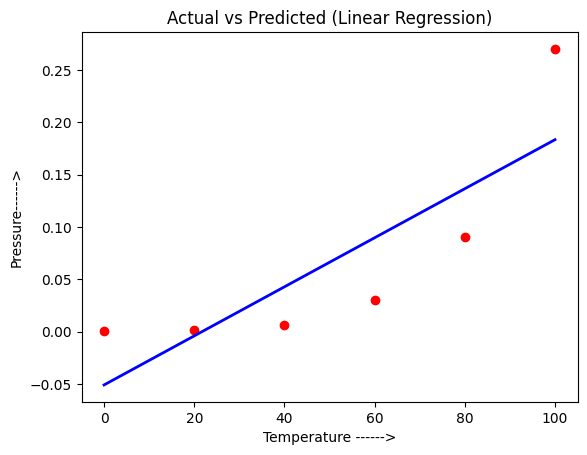

In [27]:
plt.scatter(X,y,color='red')
plt.plot(X,pred,color='blue',linewidth=2)
plt.title("Actual vs Predicted (Linear Regression)")
plt.xlabel("Temperature ------>")
plt.ylabel("Pressure------>")
plt.show()

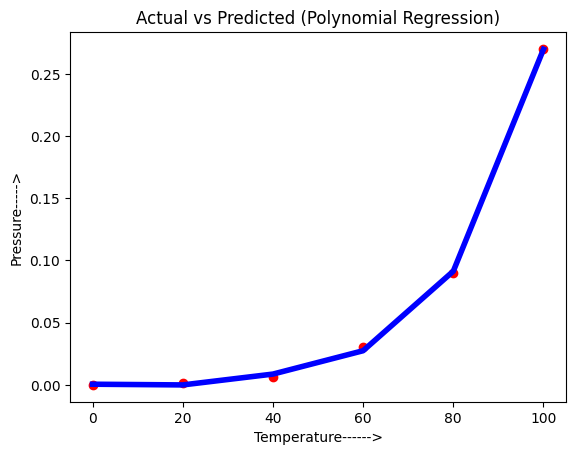

In [35]:
plt.scatter(X,y,color='red')
plt.plot(X,lr.predict(X_trans),color='blue',linewidth=4)
plt.title("Actual vs Predicted (Polynomial Regression)")
plt.xlabel("Temperature------>")
plt.ylabel("Pressure----->")
plt.show()

In [33]:
temp = 120
print(model.predict([[temp]]))

[0.23017333]
